Set Up Colab Environment - *GPU runtime: Runtime → Change runtime type → T4 GPU*

In [ ]:
!pip install transformers datasets scikit-learn pandas torch

Upload and Load CSV - Standardizing data during the merge

In [1]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

dfs = []
for filename, content in uploaded.items():
    temp_df = pd.read_csv(io.BytesIO(content))
    temp_df['source_file'] = filename

    # Standardize label column — handles all variants found in your files
    temp_df.columns = temp_df.columns.str.strip()  # remove accidental whitespace
    label_col = None
    for col in temp_df.columns:
        if col.lower() == 'severity level':
            label_col = col
            break

    if label_col:
        temp_df = temp_df.rename(columns={label_col: 'label'})
    else:
        print(f"WARNING: No severity column found in {filename} — skipping")
        continue

    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

# Drop unnamed/empty columns
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Keep only what we need
df = df[['text', 'label', 'source_file', 'createdAt', 'likeCount', 'retweetCount']].copy()

# Standardize label values (strip whitespace, title case)
df['label'] = df['label'].str.strip().str.title()

# Remove rows with missing text or label
df = df.dropna(subset=['text', 'label'])

# Remove duplicates
df = df.drop_duplicates(subset=['text'])

print(f"Total rows after cleaning: {len(df)}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nUnique label values: {df['label'].unique()}")

Saving quinta-annotated.csv to quinta-annotated.csv
Saving maring-annotated.csv to maring-annotated.csv
Saving rolly-annotated.csv to rolly-annotated.csv
Saving pepito-annotated.csv to pepito-annotated.csv
Saving paeng-annotated.csv to paeng-annotated.csv
Saving ondoy-annotated.csv to ondoy-annotated.csv
Saving enteng-annotated.csv to enteng-annotated.csv
Saving jolina-annotated.csv to jolina-annotated.csv
Saving leon-annotated.csv to leon-annotated.csv
Saving karding-annotated.csv to karding-annotated.csv
Saving ulysis-annotated.csv to ulysis-annotated.csv
Saving qc_marikina-annotated.csv to qc_marikina-annotated.csv
Saving monsoon-annotated.csv to monsoon-annotated.csv
Saving kristine-annotated.csv to kristine-annotated.csv
Saving fabian-annotated.csv to fabian-annotated.csv
Saving egay-annotated.csv to egay-annotated.csv
Saving carina-annotated.csv to carina-annotated.csv
Total rows after cleaning: 2522

Class distribution:
label
Not Relevant    2125
Mild             200
Severe     

Encode Labels and Split the Data


In [7]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch

# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# 80/10/10 split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_enc'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label_enc'])

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nTrain distribution:\n{train_df['label'].value_counts()}")

# Class weights to handle imbalance (Moderate has very few samples)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_enc']),
    y=train_df['label_enc']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("\nClass weights:", dict(zip(le.classes_, class_weights)))

Label encoding: {'Mild': np.int64(0), 'Moderate': np.int64(1), 'Severe': np.int64(2)}

Train: 316, Val: 39, Test: 40

Train distribution:
label
Mild        160
Severe      109
Moderate     47
Name: count, dtype: int64

Class weights: {'Mild': np.float64(0.6583333333333333), 'Moderate': np.float64(2.2411347517730498), 'Severe': np.float64(0.9663608562691132)}


Tokenize with RoBERTa

In [8]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize(texts, max_len=256):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )

train_enc = tokenize(train_df['text'])
val_enc   = tokenize(val_df['text'])
test_enc  = tokenize(test_df['text'])

print("Tokenization done!")
print("Sample input_ids shape:", train_enc['input_ids'].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenization done!
Sample input_ids shape: torch.Size([316, 256])


Create PyTorch Dataset and DataLoaders

In [9]:
from torch.utils.data import Dataset, DataLoader

class FloodDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_dataset = FloodDataset(train_enc, train_df['label_enc'])
val_dataset   = FloodDataset(val_enc,   val_df['label_enc'])
test_dataset  = FloodDataset(test_enc,  test_df['label_enc'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print("Datasets ready!")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Datasets ready!
Train batches: 20, Val batches: 3, Test batches: 3


Load Model and Fine-Tune

In [13]:
from transformers import RobertaForSequenceClassification
from torch.optim import AdamW
import torch.nn as nn

model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=3
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor)

EPOCHS = 15  # run more epochs, early stopping will handle it
best_val_loss = float('inf')
patience      = 3  # stop if val loss doesn't improve for 3 epochs
patience_counter = 0

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # --- Validation ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs    = model(input_ids=input_ids, attention_mask=attention_mask)
            val_loss   = loss_fn(outputs.logits, labels)
            total_val_loss += val_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), '/content/best_roberta_model.pt')
        print(f"  ✓ Best model saved at epoch {epoch+1}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# Load best model for evaluation
model.load_state_dict(torch.load('/content/best_roberta_model.pt'))
print("\nBest model loaded — ready for evaluation!")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/15 | Train Loss: 1.1304 | Val Loss: 1.0947
  ✓ Best model saved at epoch 1
Epoch 2/15 | Train Loss: 1.0963 | Val Loss: 1.0964
  No improvement (1/3)
Epoch 3/15 | Train Loss: 1.0974 | Val Loss: 1.0917
  ✓ Best model saved at epoch 3
Epoch 4/15 | Train Loss: 1.0669 | Val Loss: 1.0623
  ✓ Best model saved at epoch 4
Epoch 5/15 | Train Loss: 0.9804 | Val Loss: 0.9865
  ✓ Best model saved at epoch 5
Epoch 6/15 | Train Loss: 0.8365 | Val Loss: 0.9278
  ✓ Best model saved at epoch 6
Epoch 7/15 | Train Loss: 0.6160 | Val Loss: 1.0274
  No improvement (1/3)
Epoch 8/15 | Train Loss: 0.2654 | Val Loss: 1.2174
  No improvement (2/3)
Epoch 9/15 | Train Loss: 0.1466 | Val Loss: 1.4253
  No improvement (3/3)
Early stopping triggered at epoch 9

Best model loaded — ready for evaluation!


Evaluate on Test Set

              precision    recall  f1-score   support

        Mild       0.81      0.65      0.72        20
    Moderate       0.40      0.67      0.50         6
      Severe       0.71      0.71      0.71        14

    accuracy                           0.68        40
   macro avg       0.64      0.68      0.65        40
weighted avg       0.72      0.68      0.69        40



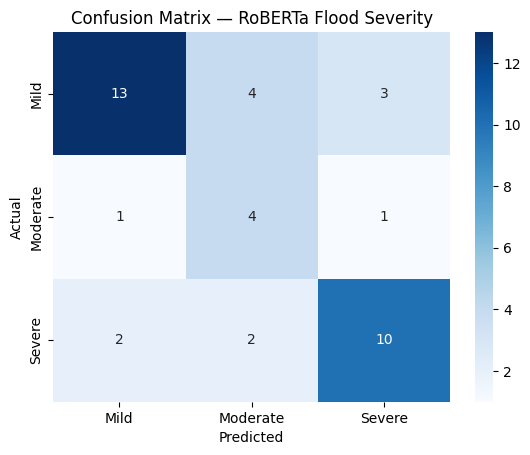

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — RoBERTa Flood Severity')
plt.show()

Save Model and Extract Embeddings for GNN

In [17]:
# Save the fine-tuned model
model.save_pretrained('/content/roberta_flood_model')
tokenizer.save_pretrained('/content/roberta_flood_model')
print("Model saved!")

# Extract [CLS] embeddings from ALL data (needed as GNN node features later)
def get_embeddings(encodings):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(encodings['input_ids']), 16):
            batch_ids  = encodings['input_ids'][i:i+16].to(device)
            batch_mask = encodings['attention_mask'][i:i+16].to(device)
            outputs    = model.roberta(input_ids=batch_ids, attention_mask=batch_mask)
            cls_emb    = outputs.last_hidden_state[:, 0, :]  # [CLS] token = 768-dim vector
            embeddings.append(cls_emb.cpu())
    return torch.cat(embeddings, dim=0)

train_embeddings = get_embeddings(train_enc)
val_embeddings   = get_embeddings(val_enc)
test_embeddings  = get_embeddings(test_enc)

# Save embeddings for GNN input later
torch.save(train_embeddings, '/content/train_text_embeddings.pt')
torch.save(val_embeddings,   '/content/val_text_embeddings.pt')
torch.save(test_embeddings,  '/content/test_text_embeddings.pt')

print(f"Embeddings shape: {train_embeddings.shape}")  # expect (n_samples, 768)
print("Embeddings saved — ready for GNN!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
Embeddings shape: torch.Size([316, 768])
Embeddings saved — ready for GNN!


**Overall Performance**

**68%** accuracy on 40 test samples — decent for a 3-class problem, but the small test set means each misclassification swings metrics significantly. The more meaningful numbers are the per-class scores.

---



Per-Class Analysis

**Mild (best performer)**

**F1: 0.72, Precision: 0.81, Recall: 0.65**

The model is conservative — it's fairly confident when it does predict Mild, but it misses 7 out of 20 actual Mild cases (4 predicted Moderate, 3 predicted Severe). High precision but low recall suggests the decision boundary is biased toward other classes.

**Severe (solid)**

**F1: 0.71, Precision: 0.71, Recall: 0.71**

Balanced and reasonable. 10/14 correct, with 2 each spilling into Mild and Moderate. Given Severe has the second-most training data (109 samples), this makes sense.

**Moderate (weakest — this the main problem)**

**F1: 0.50, Precision: 0.40, Recall: 0.67**

Only 47 training samples vs. 160 for Mild. Even with the class weight of ~2.24, it's underperforming. The model catches 4/6 actual Moderate cases, but when it predicts Moderate it's wrong 60% of the time — it's over-predicting Moderate for things that are actually Mild or Severe.

**Training Behavior — Early Overfitting**

  The model is severely overfitting from epoch 7 onward. Train loss dropped to 0.15 while val loss climbed to 1.43 — a gap of 1.28. The early stopping at patience=3 worked correctly and saved epoch 6's weights, but the fact that this divergence happens so fast suggests the model is memorizing the training set.
  
  The root cause is almost certainly the small dataset. 316 training samples is very low for fine-tuning RoBERTa, which has 125M parameters.


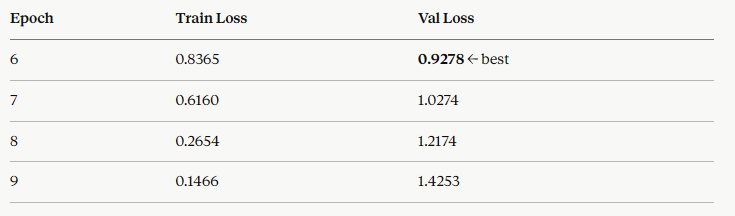

**SUMMARY**

The model works but is constrained by data size and early overfitting. The Moderate class needs the most attention before you proceed to GNN. The embedding extraction at epoch 6 (best checkpoint) is the right call — just be aware those 768-dim vectors carry the uncertainty from the Moderate confusion into your graph structure.